# Mini-Project 2: Solar Micro-Grid Dispatch Planner

**Scenario.** A rural health centre in Kasese runs a micro-grid. Each day the energy drawn from solar panels ($x$) and
batteries ($y$) must satisfy

$$3x + 2y = D_1 \quad(\text{daytime load, kWh}), \qquad 4x + y = D_2 \quad(\text{critical-equipment load, kWh}).$$

Reusable logic is in `src/microgrid/`: `grid.py` (`MicroGrid`, `HybridMicroGrid`), `demand.py` (CSV and interactive
input), `feasibility.py` (repair policies), `analysis.py` (timing, Monte Carlo) and `plotting.py`.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.core.plotting import apply_style
from src.core.stats import DescriptiveStats
from src.microgrid import (
    ClipPolicy, HybridMicroGrid, LeastCostPolicy, MicroGrid, NNLSPolicy, SingularSystemError, dispatch_with_policy,
    monte_carlo_sensitivity, read_day_interactively, read_demand_csv, simulate_demand, time_solvers,
    write_demand_csv,
)
from src.microgrid.plotting import plot_dispatch, plot_sensitivity

apply_style()
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
SEED = 2026
DATA_PATH = Path("data/kasese_demand.csv")
FIG_DIR = Path("figures"); FIG_DIR.mkdir(exist_ok=True)

## 1. The `MicroGrid` class and well-posedness

In [2]:
grid = MicroGrid()
print(grid)
diag = grid.check_well_posed()
print(f"det(A)  = {diag.determinant:.4f}   (hand: 3*1 - 2*4 = -5)")
print(f"cond(A) = {diag.condition_number:.4f}")
print(diag.describe())

MicroGrid(sources=('solar', 'battery'), A=[[3.0, 2.0], [4.0, 1.0]])
det(A)  = -5.0000   (hand: 3*1 - 2*4 = -5)
cond(A) = 5.8284
det(A) = -5 ≠ 0, so a unique dispatch exists for any demand. cond(A) = 5.83 (well-conditioned): a 1 % error in demand can move the solution by at most ~5.8 % (about 0.8 significant digits at risk).


In [3]:
# Closed form (Cramer's rule) as an independent check: x = (2*D2 - D1)/5, y = (4*D1 - 3*D2)/5
d1, d2 = 120.0, 105.0
print("solve_day:", grid.solve_day(d1, d2), "| Cramer:", [(2*d2 - d1)/5, (4*d1 - 3*d2)/5])

solve_day: [18. 33.] | Cramer: [18.0, 33.0]


**What the numbers mean.**
* $\det A = -5 \neq 0$: the two constraints are linearly independent, so **every** demand pair has exactly one
  solution. The negative sign only says the column vectors are in clockwise order. It has no physical meaning.
* $\operatorname{cond}_2(A) = \lVert A\rVert\,\lVert A^{-1}\rVert \approx 5.8$ bounds how much relative error in the
  demands can be amplified in the solution (Trefethen & Bau, 1997, Lecture 12): $\frac{\lVert\Delta s\rVert}{\lVert s\rVert} \le \kappa(A)\frac{\lVert\Delta d\rVert}{\lVert d\rVert}$.
  A 1 % metering error can move the dispatch by up to about 6 %. That is a well-conditioned system; trouble starts
  around $\kappa \gtrsim 10^3$ and numerical breakdown near $10^{16}$.
* A unique solution is not necessarily feasible. The closed form shows $y \ge 0 \iff D_2/D_1 \le 4/3$ and $x \ge 0 \iff D_2/D_1 \ge 1/2$.
  Days outside that ratio band have a unique but physically impossible solution (Task 4).

## 2. Two input modes

### (a) Interactive entry with validation
`prompt_non_negative_float` rejects empty, non-numeric, negative, `nan` and `inf` input and asks again. `input()` would
block *Restart & Run All*, so the notebook injects a scripted sequence of answers by default. Set
`INTERACTIVE = True` to type values yourself.

In [4]:
INTERACTIVE = False

if INTERACTIVE:
    day = read_day_interactively()
else:
    scripted = iter(["", "one hundred", "-40", "118.5", "nan", "101"])
    def fake_input(prompt: str) -> str:
        answer = next(scripted)
        print(f"{prompt}{answer!r}")
        return answer
    day = read_day_interactively(input_fn=fake_input)

print("Accepted:", day, "-> dispatch (solar, battery) =", grid.solve_day(*day).round(2))

Daytime load D1 (kWh): ''
  ✗ Please enter a value (input was empty).
Daytime load D1 (kWh): 'one hundred'
  ✗ 'one hundred' is not a number.
Daytime load D1 (kWh): '-40'
  ✗ Demand cannot be negative.
Daytime load D1 (kWh): '118.5'
Critical-equipment load D2 (kWh): 'nan'
  ✗ The value must be a finite number.
Critical-equipment load D2 (kWh): '101'
Accepted: (118.5, 101.0) -> dispatch (solar, battery) = [16.7 34.2]


### (b) 30 days from CSV

The CSV is generated with a seeded generator (`simulate_demand`) and a realistic weekly pattern:
* **D1, daytime load.** ~120 kWh on weekdays when the outpatient clinic runs, ~90 kWh on Saturday and ~74 kWh on Sunday.
* **D2, critical load.** Vaccine fridges, oxygen concentrators and theatre lighting draw a roughly constant ~105 kWh
  every day.
* Gaussian noise (σ = 6 and 5 kWh) on top.

The file is written once and then **read back** through the validating loader, so the analysis runs on exactly what is
on disk.

In [5]:
write_demand_csv(simulate_demand(30, seed=SEED), DATA_PATH)
schedule = read_demand_csv(DATA_PATH)
demands = schedule.matrix           # shape (2, 30)
print(DATA_PATH.read_text().splitlines()[:4], "...")
print("days loaded:", len(schedule), "| demand matrix shape:", demands.shape)

['date,weekday,d1_kwh,d2_kwh', '2026-10-01,Thu,115.2,99.2', '2026-10-02,Fri,121.4,111.8', '2026-10-03,Sat,78.6,109.2'] ...
days loaded: 30 | demand matrix shape: (2, 30)


## 3. Loop vs vectorised solve

In [6]:
loop_sol = grid.solve_days_loop(demands)
vec_sol = grid.solve_days(demands)
print("max |loop - vectorised| =", np.abs(loop_sol - vec_sol).max())

timing = time_solvers(grid, demands, number=200, repeat=5)
print(f"loop       : {timing.loop_seconds*1e6:8.1f} µs per 30-day batch")
print(f"vectorised : {timing.vectorised_seconds*1e6:8.1f} µs per 30-day batch")
print(f"speed-up   : {timing.speedup:.1f}×")

max |loop - vectorised| = 0.0


loop       :    230.1 µs per 30-day batch
vectorised :     24.3 µs per 30-day batch
speed-up   : 9.5×


**Comment.** Both approaches give identical answers to machine precision, but the vectorised call is much faster.
The loop pays Python and SciPy call overhead 30 times: argument checking, the `check_finite` scan and array conversion.
It also **re-factorises the same matrix $A$ 30 times**. `scipy.linalg.solve(A, B)` with a $2\times30$ right-hand side
performs one LU factorisation and 30 cheap triangular back-substitutions (Golub & Van Loan, 2013, §3.1) inside compiled LAPACK. The arithmetic here is
trivial, so the gap is almost entirely overhead, and it grows linearly with the number of days.

## 4. Infeasible days and handling strategy

In [7]:
plans = {p.name: dispatch_with_policy(grid, demands, p) for p in (ClipPolicy(), NNLSPolicy(), LeastCostPolicy())}
bad = plans["clip"].infeasible_days
print(f"Infeasible days: {len(bad)} of {len(schedule)} (feasible band 0.50 ≤ D2/D1 ≤ 1.33)")
display(pd.DataFrame({"date": [schedule.dates[j].strftime("%a %d %b") for j in bad],
                      "D1": demands[0, bad], "D2": demands[1, bad], "D2/D1": demands[1, bad] / demands[0, bad],
                      "raw x": plans["clip"].raw[0, bad], "raw y": plans["clip"].raw[1, bad]}).set_index("date"))

rows = []
for name, p in plans.items():
    for j in bad:
        rows.append({"policy": name, "date": schedule.dates[j].strftime("%a %d"),
                     "solar x": p.dispatch[0, j], "battery y": p.dispatch[1, j],
                     "unmet daytime": p.unmet[0, j], "unmet CRITICAL": p.unmet[1, j],
                     "curtailed (D1+D2)": p.curtailed[:, j].sum(), "cost UGX": p.daily_cost[j]})
pd.DataFrame(rows).set_index(["policy", "date"])

Infeasible days: 3 of 30 (feasible band 0.50 ≤ D2/D1 ≤ 1.33)


,D1,D2,D2/D1,raw x,raw y
date,,,,,
Sat 03 Oct,78.60,109.20,1.39,27.96,-2.64
Sun 04 Oct,82.40,110.70,1.34,27.80,-0.50
Sun 11 Oct,78.30,106.00,1.35,26.74,-0.96


solar x  battery y  unmet daytime  unmet CRITICAL  \
policy        date                                                        
clip          Sat 03    27.96       0.00           0.00            0.00   
              Sun 04    27.80       0.00           0.00            0.00   
              Sun 11    26.74       0.00           0.00            0.00   
nnls          Sat 03    26.90       0.00           0.00            1.58   
              Sun 04    27.60       0.00           0.00            0.30   
              Sun 11    26.36       0.00           0.00            0.58   
least-cost LP Sat 03    27.30       0.00           0.00            0.00   
              Sun 04    27.68       0.00           0.00            0.00   
              Sun 11    26.50       0.00           0.00            0.00   

                      curtailed (D1+D2)  cost UGX  
policy        date                                 
clip          Sat 03               7.92  4,194.00  
              Sun 04               1.50  4,170.00  
              Sun 11               2.88  4,011.00  
nnls          Sat 03               2.11  4,035.60  
              Sun 04               0.40  4,140.00  
              Sun 11               0.77  3,953.40  
least-cost LP Sat 03               3.30  4,095.00  
              Sun 04               0.62  4,151.25  
              Sun 11               1.20  3,975.00

All infeasible days are **weekends**. Daytime load drops when the clinic closes, but the critical load does not, so
$D_2/D_1$ rises above $4/3$ and the exact solution needs a *negative* battery draw, i.e. the battery would have to absorb
daytime energy while also counting towards the load.

Three repair strategies (interchangeable `FeasibilityPolicy` strategy objects) are compared:

| Policy | Idea | Verdict |
|---|---|---|
| **Clip** | zero the negative source, keep the other | meets both loads here (removing a negative draw only adds supply), but wastes the most energy (~8 kWh curtailed on 3 Oct) and costs more than the LP |
| **NNLS** (`scipy.optimize.nnls`; Lawson & Hanson, 1995) | non-negative dispatch minimising $\lVert As-d\rVert_2$ | smallest total mismatch (next cell), **but it leaves critical load unmet** |
| **Least-cost LP** (`scipy.optimize.linprog`, HiGHS solver; Huangfu & Hall, 2018) | minimise cost s.t. $As \ge d,\ s \ge 0$ | always meets both loads; curtails the small surplus; cheapest such plan |

NNLS treats a kWh of shortfall and a kWh of surplus as equally bad. In a health centre they are not: an unpowered
vaccine fridge or oxygen concentrator is a clinical risk, whereas surplus solar can simply be curtailed. The
**least-cost LP** encodes that asymmetry. On each infeasible day it switches the battery off and sizes solar to the
critical load exactly ($x = D_2/4$), which also covers the reduced daytime load. **We adopt it for the rest of the
analysis** and report the curtailed energy explicitly rather than hiding it.

In [8]:
print("Mismatch ‖A s − d‖ (kWh) on infeasible days:")
for j in bad:
    print(f"  {schedule.dates[j]:%a %d}: " + " | ".join(
        f"{name} {np.linalg.norm(p.residual[:, j]):5.2f}" for name, p in plans.items()))
plan = plans["least-cost LP"]
print(f"\nChosen: {plan.policy_name}; total unmet over the month = {plan.unmet.sum():.2f} kWh, "
      f"curtailed = {plan.curtailed.sum():.2f} kWh")

Mismatch ‖A s − d‖ (kWh) on infeasible days:
  Sat 03: clip  5.90 | nnls  2.64 | least-cost LP  3.30
  Sun 04: clip  1.12 | nnls  0.50 | least-cost LP  0.62
  Sun 11: clip  2.15 | nnls  0.96 | least-cost LP  1.20

Chosen: least-cost LP; total unmet over the month = 0.00 kWh, curtailed = 5.13 kWh


## 5. Usage statistics (with `statistics`)

In [9]:
usage_stats = {src: DescriptiveStats.from_statistics(plan.dispatch[i]) for i, src in enumerate(grid.sources)}
usage_df = pd.DataFrame({src: {**s.as_dict(), "CV": s.cv} for src, s in usage_stats.items()}).T
usage_df

,n,mean,median,variance,stdev,CV
solar,30.00,20.93,19.95,17.98,4.24,0.20
battery,30.00,23.61,29.78,206.97,14.39,0.61


In [10]:
most_volatile_abs = max(usage_stats, key=lambda k: usage_stats[k].stdev)
most_volatile_rel = max(usage_stats, key=lambda k: usage_stats[k].cv)
print(f"Largest standard deviation: {most_volatile_abs}; largest coefficient of variation: {most_volatile_rel}")

Largest standard deviation: battery; largest coefficient of variation: battery


**The battery is by far the more volatile source.** Its daily draw has a much larger standard deviation and CV than
solar. From the closed form $y = (4D_1 - 3D_2)/5$, the battery absorbs *every* swing in daytime load with weight 4/5,
and the noise in both demands adds up. Solar, $x = (2D_2 - D_1)/5$, has smaller coefficients and partially cancelling
terms. Operationally, the weekly clinic cycle shows up as deep weekday-to-weekend swings in battery throughput,
which matters for battery wear (cycle depth).

## 6. Cost model (solar UGX 150/kWh, battery UGX 450/kWh)

In [11]:
cost = pd.DataFrame({"date": [d.strftime("%a %d") for d in schedule.dates],
                     "solar kWh": plan.dispatch[0], "battery kWh": plan.dispatch[1],
                     "daily cost (UGX)": plan.daily_cost}).set_index("date")
display(cost.head(7))
print(f"Monthly (30-day) cost: UGX {plan.total_cost:,.0f}")
print(f"Mean daily cost:       UGX {plan.daily_cost.mean():,.0f}  (min {plan.daily_cost.min():,.0f}, max {plan.daily_cost.max():,.0f})")
print(f"Hand check day 1: 150*{plan.dispatch[0,0]:.2f} + 450*{plan.dispatch[1,0]:.2f} = "
      f"{150*plan.dispatch[0,0] + 450*plan.dispatch[1,0]:,.0f}")
print(f"Battery share of cost: {450*plan.dispatch[1].sum() / plan.total_cost:.0%} "
      f"(share of energy: {plan.dispatch[1].sum() / plan.dispatch.sum():.0%})")

,solar kWh,battery kWh,daily cost (UGX)
date,,,
Thu 01,16.64,32.64,"17,184.00"
Fri 02,20.44,30.04,"16,584.00"
Sat 03,27.30,0.00,"4,095.00"
Sun 04,27.68,0.00,"4,151.25"
Mon 05,15.48,38.68,"19,728.00"
Tue 06,19.72,29.52,"16,242.00"
Wed 07,17.34,33.04,"17,469.00"


Monthly (30-day) cost: UGX 412,874
Mean daily cost:       UGX 13,762  (min 3,975, max 21,168)
Hand check day 1: 150*16.64 + 450*32.64 = 17,184
Battery share of cost: 77% (share of energy: 53%)


## 7. Stacked daily dispatch with daily cost

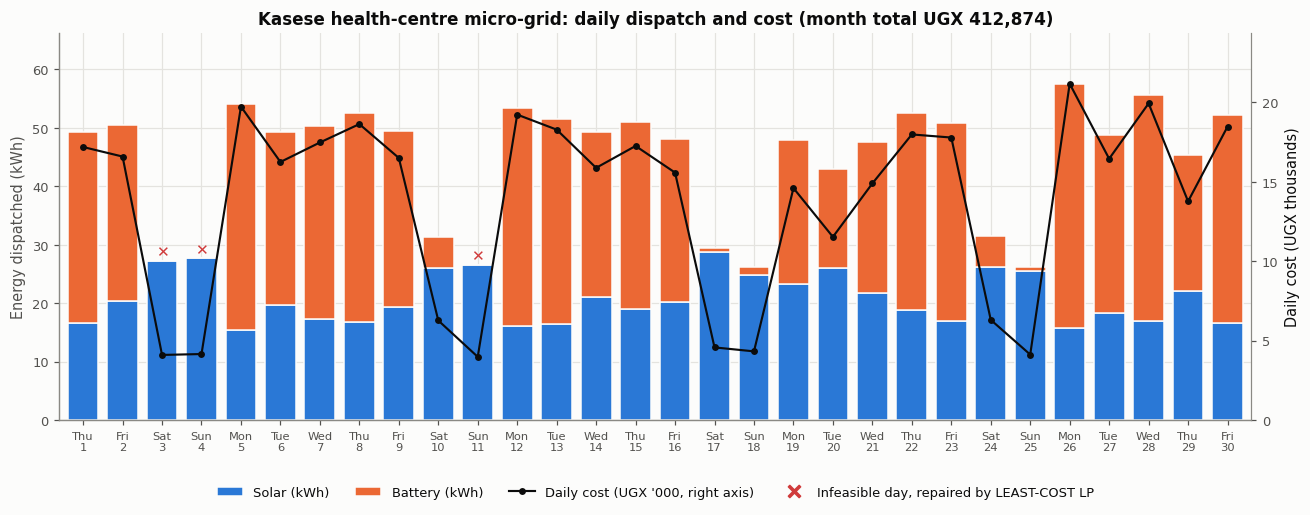

In [12]:
fig = plot_dispatch(plan, schedule)
fig.savefig(FIG_DIR / "p2_dispatch.png", bbox_inches="tight")
plt.show()

The chart shows the volatility result from Task 5. The solar layer is nearly flat, while the battery layer (and with it the
cost line, since battery energy costs 3× as much) follows the clinic's week. Weekend days are cheapest but include
the infeasible ✕ days, so the weekend is where the choice of dispatch rule matters most.

## Extension A: `HybridMicroGrid` with a diesel generator

`HybridMicroGrid(MicroGrid)` inherits all solving, validation and cost logic. It only overrides the class-level
defaults (3×3 matrix, source names, tariffs). The third constraint is a **night-time load**, which solar cannot serve:

$$3x + 2y + z = D_1,\quad 4x + y + 2z = D_2,\quad 3y + 2z = D_3.$$

In [13]:
hybrid = HybridMicroGrid()
print(hybrid)
print(hybrid.check_well_posed().describe())
demand3 = (120.0, 110.0, 130.0)
print(f"Dispatch for D = {demand3}:", {k: round(float(v), 2) for k, v in zip(hybrid.sources, hybrid.solve_day(*demand3))})
print(f"Daily cost: UGX {hybrid.daily_cost(hybrid.solve_day(*demand3))[0]:,.0f}")

HybridMicroGrid(sources=('solar', 'battery', 'diesel'), A=[[3.0, 2.0, 1.0], [4.0, 1.0, 2.0], [0.0, 3.0, 2.0]])
det(A) = -16 ≠ 0, so a unique dispatch exists for any demand. cond(A) = 7.18 (well-conditioned): a 1 % error in demand can move the solution by at most ~7.2 % (about 0.9 significant digits at risk).
Dispatch for D = (120.0, 110.0, 130.0): {'solar': 12.5, 'battery': 35.0, 'diesel': 12.5}
Daily cost: UGX 32,625


In [14]:
# A linearly dependent third constraint: row3 = row1 + row2.
broken = HybridMicroGrid.with_dependent_constraint()
print(broken.coefficients)
print(broken.conditioning().describe())
try:
    broken.solve_day(120, 105, 225)
except SingularSystemError as err:
    print("\nSingularSystemError raised as designed.")

# What happens mathematically: consistent RHS -> infinitely many solutions (a line); inconsistent -> none.
A3 = broken.coefficients
for d3 in (225.0, 230.0):
    sol, res, rank, _ = np.linalg.lstsq(A3, [120, 105, d3], rcond=None)
    print(f"D3={d3:.0f}: rank={rank}, min-norm solution={sol.round(2)}, residual={np.linalg.norm(A3@sol-[120,105,d3]):.3f}")

[[3. 2. 1.]
 [4. 1. 2.]
 [7. 3. 3.]]
det(A) = 1.31e-15 and cond(A) = 4.56e+16: the system is singular, so the constraints are linearly dependent and there is either no dispatch or infinitely many.

SingularSystemError raised as designed.
D3=225: rank=2, min-norm solution=[18.95 32.37 -1.58], residual=0.000
D3=230: rank=2, min-norm solution=[19.25 32.72 -1.54], residual=2.887


If the new equation is a linear combination of the others (here row 3 = row 1 + row 2), then $\det A = 0$ (up to
rounding, ~1e-15), $\kappa(A)\approx10^{16}$, and the matrix has rank 2. The third constraint adds **no new
information**. If $D_3 = D_1 + D_2$ the system is consistent but has infinitely many solutions: a whole line of
dispatches meets demand, and an extra criterion (e.g. minimum cost) must pick one. Otherwise the constraints
contradict each other and **no** dispatch exists (least squares leaves a non-zero residual). `check_well_posed()`
catches this before `scipy.linalg.solve` returns numerically meaningless numbers.

## Extension B: Monte Carlo sensitivity (±5 %, 1,000 draws)

In [15]:
base = np.array([120.0, 105.0])
sens = monte_carlo_sensitivity(grid, base, relative_perturbation=0.05, n_draws=1000, rng=np.random.default_rng(SEED))
rel = sens.relative_source_change * 100
pd.DataFrame({"solar Δ%": rel[:, 0], "battery Δ%": rel[:, 1], "amplification": sens.amplification}).describe(
    percentiles=[0.05, 0.5, 0.95]).T

,count,mean,std,min,5%,50%,95%,max
solar Δ%,"1,000.00",-0.03,7.75,-17.63,-12.80,-0.13,12.62,16.85
battery Δ%,"1,000.00",0.22,10.07,-22.10,-16.06,0.49,16.53,23.34
amplification,"1,000.00",3.05,1.34,0.79,0.86,3.33,4.57,4.58


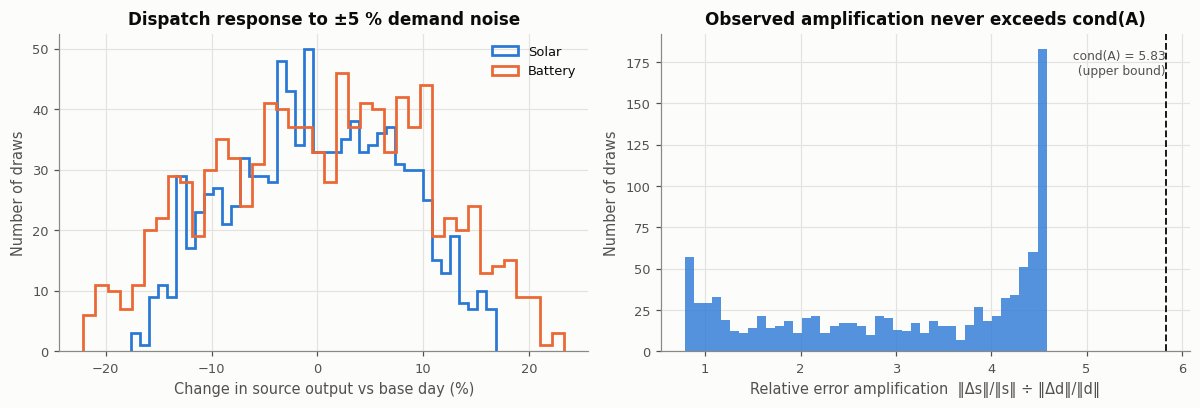

max amplification observed = 4.58 ≤ cond(A) = 5.83


In [16]:
fig = plot_sensitivity(sens, grid.sources, diag.condition_number)
fig.savefig(FIG_DIR / "p2_sensitivity.png", bbox_inches="tight")
plt.show()
print(f"max amplification observed = {sens.amplification.max():.2f} ≤ cond(A) = {diag.condition_number:.2f}")

A ±5 % perturbation of the demands moves solar by up to ~±17 % and the battery by up to ~±23 % at this operating point
(90 % of draws within about ±13 % and ±16 %). Each source is a *difference* of scaled demands, and differences
amplify relative error. The amplification factor has a median of ~3.3 and a maximum of ~4.6. It never exceeds
$\kappa(A)\approx5.8$, and it cannot reach it here because the bound requires the perturbation to line up exactly with
$A$'s weakest singular direction *relative to the base demand*. Independent ±5 % shocks to each demand rarely do
that. The condition number is a worst-case guarantee, not a typical value. In practice, metering errors of a few percent can
produce battery-scheduling errors several times larger.

## References

* Golub, G. H. & Van Loan, C. F. (2013). *Matrix Computations* (4th ed.). Johns Hopkins University Press.
* Huangfu, Q. & Hall, J. A. J. (2018). Parallelizing the dual revised simplex method. *Mathematical Programming Computation*, 10, 119–142.
* Lawson, C. L. & Hanson, R. J. (1995). *Solving Least Squares Problems*. SIAM.
* Python Software Foundation. `timeit` documentation. https://docs.python.org/3/library/timeit.html
* Trefethen, L. N. & Bau, D. (1997). *Numerical Linear Algebra*. SIAM.

## Findings & Limitations

**Findings.** With $\det A=-5$ and $\kappa(A)\approx5.8$, every demand pair has
a unique, numerically stable dispatch. The practical difficulty is physical feasibility. Three of the 30 days, all
weekends, are infeasible: the critical load stays at ~105 kWh while clinic load falls, pushing $D_2/D_1$ above 4/3. The
repair policy is therefore partly a clinical decision. NNLS minimises mismatch, but it would
leave up to 1.6 kWh of *critical* load unserved. The least-cost LP serves all load and costs at most UGX 60 more on the
worst day, so it is the defensible choice.

The battery is both the volatile and the expensive source. Its CV is 0.61 against 0.20 for solar, and it supplies 53 %
of the energy but 77 % of the ~UGX 413,000 monthly cost. The biggest saving therefore comes from cutting weekday
battery throughput, for example by moving deferrable loads (sterilisation, laundry, water pumping) into peak sun.
Vectorised solving was ~10× faster than the loop. That is irrelevant for 30 days but matters for Monte Carlo
planning. Demand errors of ±5 % moved the battery schedule by up to ±23 %, within the $\kappa(A)$ bound but large
enough to justify accurate metering.

**Limitations.** The coefficient matrix is taken from the brief without a physical derivation, so the conclusions are
only as meaningful as $A$. Treating each day as an independent equality system ignores battery state of charge,
capacity and round-trip losses: in reality the battery can only discharge what solar previously stored. A multi-period
LP with storage dynamics and weather-dependent PV output (cloudy rainy seasons) would be the next step. Demand is
synthetic with Gaussian noise and no outages. The tariffs are illustrative marginal costs that ignore battery wear.